# Exploring the Paul concordance

Interactive reading of the scan produced by [`scripts/paul_concordance.py`](paul_concordance.py).
Nothing here changes the detector — it only reads its outputs.

**Read first:** `data/large_files/paul_scan/RUN_STATE.md`. Its caveats are load-bearing:

* **tier A and B are the trustworthy counts; tier C is context-resolved, not verified** —
  82% of it carries no flag, but residual false positives are unmeasured. Do not quote tier C
  as a count of references to the apostle.
* `pattern:` totals exceed `tier:` totals because of deliberate tier demotion
  (4,507 rows, flagged `demoted_name_after`). Never quote `pattern:A6` as a tier-A count.
* Greek `Παῦλος`/`Σαῦλος` is unmatched; `references_txts/` is not scanned.

| what | path |
| --- | --- |
| detector | `scripts/paul_concordance.py` |
| all outputs | `data/large_files/paul_scan/` (gitignored) |
| corpus the offsets index into | `/srv/data/jstor/jstor2026-04/fulltexts_txts/<item_id>.txt` |


## 1 · Load

`hits.tsv.gz` is ~570 MB uncompressed and takes ~15 s to read, so it is cached as parquet
next to it. Delete `hits.parquet` after any re-run of the scan to invalidate the cache.

In [2]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})

In [3]:
SCAN = Path("/home/jupyter-vojta/notebooks/mops/data/large_files/paul_scan")
ROOT = SCAN.parents[2]            # .../mops — holds scripts/

ROOT = SCAN.parents[2]            # .../mops — holds scripts/

JSTOR_TEXTS = Path("/srv/data/jstor/jstor2026-04/fulltexts_txts")
METADATA_CSV = Path("/srv/data/jstor/jstor2026-04/jstor_metadata_2026-04-28-filtered.csv")

In [10]:
_cache = SCAN / "hits.parquet"
if _cache.exists() and _cache.stat().st_mtime > (SCAN / "hits.tsv.gz").stat().st_mtime:
    hits = pd.read_parquet(_cache)
else:
    hits = pd.read_csv(SCAN / "hits.tsv.gz", sep="	", low_memory=False)
    hits.to_parquet(_cache)

by_doc = pd.read_csv(SCAN / "hits_by_doc.tsv.gz", sep="	")
report = json.loads((SCAN / "scan_report.json").read_text())

print(f"scan of {report['generated']}: {report['hits']:,} hits in "
      f"{report['documents_with_hits']:,} of {report['documents_scanned']:,} articles "
      f"({report['seconds']} s)")
hits.head(3)


scan of 2026-09-29 21:26:32: 426,917 hits in 69,709 of 384,807 articles (303.2 s)


,item_id,year,bidecade,journal,language,tier,pattern,flags,char_start,char_end,match,kwic_left,kwic_right,sentence,doc_len
0,00007d84-bef1-382f-9f41-439ef5607034,1991,1980-1999,The Journal of Symbolic Logic,eng,B,A5_pauline_writings,capital_after;possibly_given_name;excluded_nam...,16387,16402,writing of Paul,…account of quantification found in the,Lorenzen ([2] and [3]). REFERENCES [1]…,In this we make use of the account of quantifi...,45720
1,0001635d-ebb6-300e-90a3-d87b259efc7d,2020,2020-2039,Revue Philosophique de la France et de l'Étranger,fre,B,B2_paulus,capital_after,30862,30868,Paulus,"…und im spekulativen Idealismus », in","Engelhardt (éd.), Sein und Ethos.…","Voir Dieter Henrich, « Das Problem der Grund- ...",55546
2,0001ab79-c8bb-3d8f-bd97-8fb2467adc14,1922,1920-1939,Zeitschrift für Theologie und Kirche,ger,B,B2_paulus,capital_after,1456,1462,Paulus,"…Studien und Kritiken"" erscheinen.",", Geschichtl. u. übergeschichtl.…","Paulus, Geschichtl. u. übergeschichtl.",70153


### Flags as columns

`flags` is a `;`-joined string. Expanding it into boolean columns makes the
uncertainty visible and filterable — this is the column to reason about, not the tier alone.

In [12]:
ALL_FLAGS = sorted({f for row in hits["flags"].dropna() for f in row.split(";") if f})
for f in ALL_FLAGS:
    hits[f"f_{f}"] = hits["flags"].str.contains(rf"(?:^|;){re.escape(f)}(?:$|;)", regex=True, na=False)
hits["n_flags"] = hits["flags"].fillna("").str.split(";").apply(
    lambda fs: sum(bool(f) for f in fs))
hits["flagged"] = hits["n_flags"] > 0
ALL_FLAGS


['capital_after',
 'citation_apparatus',
 'demoted_name_after',
 'excluded_name',
 'initial_after',
 'initial_before',
 'papacy_or_numeral',
 'place_or_building',
 'possibly_given_name',
 'probably_person_name',
 'running_head']

## 2 · Scale: what each tier actually contains

`hits.tsv.gz` keeps **every** row; only the `concordance_*.txt` listings apply the
presentation filter (`--fp-filter`, tier C only). So the tables below are larger than
what those text files show.

In [13]:
tier_tbl = (hits.groupby("tier")
            .agg(hits=("item_id", "size"),
                 articles=("item_id", "nunique"),
                 journals=("journal", "nunique"),
                 flagged=("flagged", "mean"))
            .rename(columns={"flagged": "% flagged"}))
tier_tbl["% of corpus articles"] = (tier_tbl["articles"] / report["documents_scanned"]).mul(100)
display(tier_tbl)

(pd.crosstab(hits["pattern"], hits["tier"])
   .assign(total=lambda d: d.sum(axis=1))
   .sort_values("total", ascending=False))


,hits,articles,journals,% flagged,% of corpus articles
tier,,,,,
A,76163,26263,303,0.165527,6.824980
B,145240,27708,306,0.252410,7.200493
C,205514,41403,311,0.187812,10.759420


tier,A,B,C,total
pattern,,,,
C1_paul_then_lowercase,0,0,105682,105682
C4_the_paul,0,0,61057,61057
A6_saint_paul,51500,707,0,52207
B3_of_paul,0,47328,3146,50474
B2_paulus,0,49547,70,49617
B1_pauline_adj,0,39657,300,39957
C2_paul_possessive,0,0,25372,25372
A5_pauline_writings,16902,276,0,17178
C3_paul_verb,0,0,9885,9885


> Rows where `total` > the tier-A column are the demoted ones — a hit whose *pattern* is
> explicit but whose *context* names a modern Paul, so the detector pushed it down a tier.

In [14]:
_token_re = re.compile(r"\w+", flags=re.UNICODE)

hits["kwic_tokens"] = [
    _token_re.findall(f"{l} {r}")
    for l, r in zip(hits["kwic_left"].fillna(""), hits["kwic_right"].fillna(""))
]


In [15]:
hits[(hits["tier"]=="C") & hits["flags"].isnull()].sample(10)

,item_id,year,bidecade,journal,language,tier,pattern,flags,char_start,char_end,...,f_initial_after,f_initial_before,f_papacy_or_numeral,f_place_or_building,f_possibly_given_name,f_probably_person_name,f_running_head,n_flags,flagged,kwic_tokens
41094,18c3869d-f937-32ab-b80a-922e58c5492f,2019,2000-2019,Novum Testamentum,eng,C,C1_paul_then_lowercase,None,6266,6271,...,None,None,None,None,None,None,None,0,False,"[Sin, and, the, Deception, of, Devout, Desire,..."
263809,a08a5b25-c3ad-3e8e-840f-ffe97ee5ec34,1945,1940-1959,Tijdschrift voor Philosophie,dut,C,C1_paul_then_lowercase,None,126239,126244,...,None,None,None,None,None,None,None,0,False,"[Delbrück, Wackernagel, Ries, Hermann, minsten..."
257236,9c59c88b-7582-3f6e-84f2-1b9fc1207463,1983,1980-1999,Biblica,eng,C,C1_paul_then_lowercase,None,33218,33223,...,None,None,None,None,None,None,None,0,False,"[is, not, to, be, crudely, understood, never, ..."
212087,80902c14-5230-3e6a-99c7-7dff930a2cdf,2019,2000-2019,Biblica,eng,C,C3_paul_verb,None,22034,22048,...,None,None,None,None,None,None,None,0,False,"[For, if, the, human, predicament, is, not, as..."
331972,c81b6b70-d0af-37cd-8595-a6d5dfbf0786,1923,1920-1939,Journal of Biblical Literature,eng,C,C1_paul_then_lowercase,None,24629,24634,...,None,None,None,None,None,None,None,0,False,"[KOVla, TJ79, KaLtv7, LaO, Kr0Sg, to, which, w..."
147210,5a30a3ec-72f2-3a74-8b4d-547d179057a1,2020,2020-2039,Buddhist-Christian Studies,eng,C,C1_paul_then_lowercase,None,41847,41852,...,None,None,None,None,None,None,None,0,False,"[of, Christ, soma, Christou, In, Rom, 12, talk..."
249109,9758c1e1-66af-300e-b9b0-a0ce1ac79634,1894,1880-1899,Revue de Théologie et de Philosophie et Compte...,fre,C,C1_paul_then_lowercase,None,9098,9103,...,None,None,None,None,None,None,None,0,False,"[comprend, que, le, conflit, qui, surgit, entr..."
421093,fc50809d-68b5-3dfb-8fea-587d7ac50ed5,2014,2000-2019,The Catholic Historical Review,eng,C,C1_paul_then_lowercase,None,5727,5732,...,None,None,None,None,None,None,None,0,False,"[Elected, to, the, pontificate, in, 1978, John..."
105853,40f77dd2-448a-316e-af99-357fc7442993,2012,2000-2019,The Catholic Biblical Quarterly,eng,C,C2_paul_possessive,None,56219,56225,...,None,None,None,None,None,None,None,0,False,"[w, 24, 26, have, a, retributive, context, jus..."
335047,c9c27d49-ed1a-3fe9-ade9-3b93688728df,2013,2000-2019,Novum Testamentum,eng,C,C4_the_paul,None,16954,16961,...,None,None,None,None,None,None,None,0,False,"[Son, of, God, language, is, much, more, akin,..."


## 3 · Time

`year` comes from the metadata; `bidecade` is precomputed for slicing with the older
2022–2025 pipeline, whose periods were `1900-1919 … 2000-2019`.

/tmp/ipykernel_2708977/104944350.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .pipe(lambda d: pd.to_datetime(d["published_date"], errors="coerce").dt.year) \


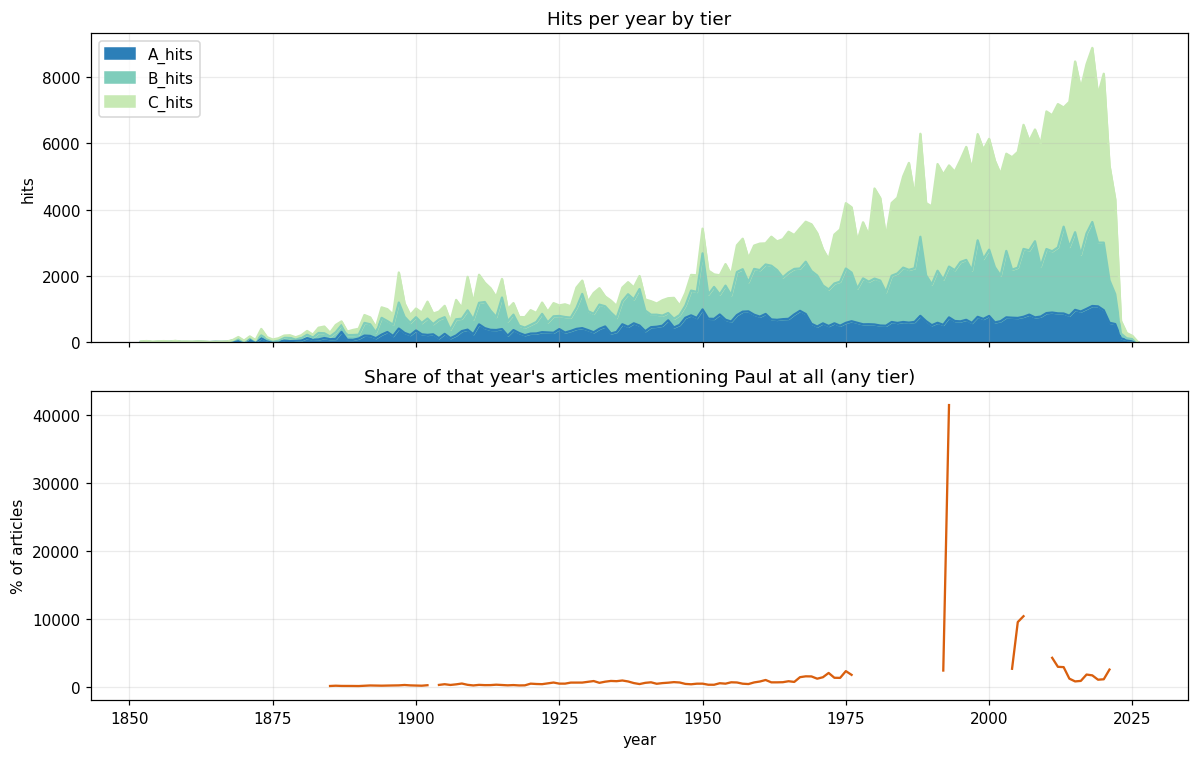

,A_hits,B_hits,C_hits,articles_with_hit,articles_total
year,,,,,
2019,1084,1922,4452,1267,124.0
2020,969,2037,5093,1185,109.0
2021,590,1278,3463,981,39.0
2022,551,901,2861,844,0.0
2023,119,143,383,179,0.0
2024,73,49,157,120,0.0
2025,62,34,98,70,0.0
2026,0,0,2,1,0.0


In [16]:
per_year = (hits.groupby(["year", "tier"]).size().unstack(fill_value=0)
                .rename_axis(None, axis=1).add_suffix("_hits"))
per_year["articles_with_hit"] = (by_doc.groupby("year")["tier_a"].size())
per_year["articles_total"] = pd.read_csv(METADATA_CSV, usecols=["published_date"]) \
        .pipe(lambda d: pd.to_datetime(d["published_date"], errors="coerce").dt.year) \
        .value_counts().rename("articles_total")
per_year = per_year.fillna(0)

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
yr = per_year.index.to_series()
keep = yr.between(1850, report_year_max := int(yr.max()))
per_year = per_year[keep]
per_year[["A_hits", "B_hits", "C_hits"]].plot.area(ax=ax[0], stacked=True,
                                                   color=["#2c7fb8", "#7fcdbb", "#c7e9b4"])
ax[0].set_ylabel("hits")
ax[0].set_title("Hits per year by tier")
(100 * per_year["articles_with_hit"] / per_year["articles_total"]).plot(ax=ax[1], color="#d95f0e")
ax[1].set_ylabel("% of articles"); ax[1].set_xlabel("year")
ax[1].set_title("Share of that year's articles mentioning Paul at all (any tier)")
fig.tight_layout(); plt.show()
per_year.tail(8)


## 4 · Journals

Raw counts rank by journal size, which is not the interesting question — **density** is:
what share of a journal's articles mention Paul. The corpus is Philosophy ∪ Religion, so
`Synthese` at ~0.6% and `Novum Testamentum` at ~37% are the two ends of the same corpus.

,with_hit,tier_a,tier_b,tier_c,articles,% articles w/ hit,A hits / article
journal,,,,,,,
Bulletin de théologie ancienne et médiévale,107,500,371,164,122,87.704918,4.098361
Neotestamentica,638,1938,5676,15106,879,72.582480,2.204778
Novum Testamentum,813,2458,10086,17388,1256,64.729299,1.957006
Revue de Théologie et de Philosophie et Compte-rendu des Principales Publications Scientifiques,475,1299,1251,1842,829,57.297949,1.566948
Theologische Rundschau,690,509,9864,522,1207,57.166529,0.421707
Zeitschrift für Theologie und Kirche,1260,541,18829,395,2269,55.531071,0.238431
U.S. Catholic Historian,501,817,266,457,928,53.987069,0.880388
The American Journal of Theology,334,855,1463,2506,623,53.611557,1.372392
Church History and Religious Culture,155,162,123,358,296,52.364865,0.547297


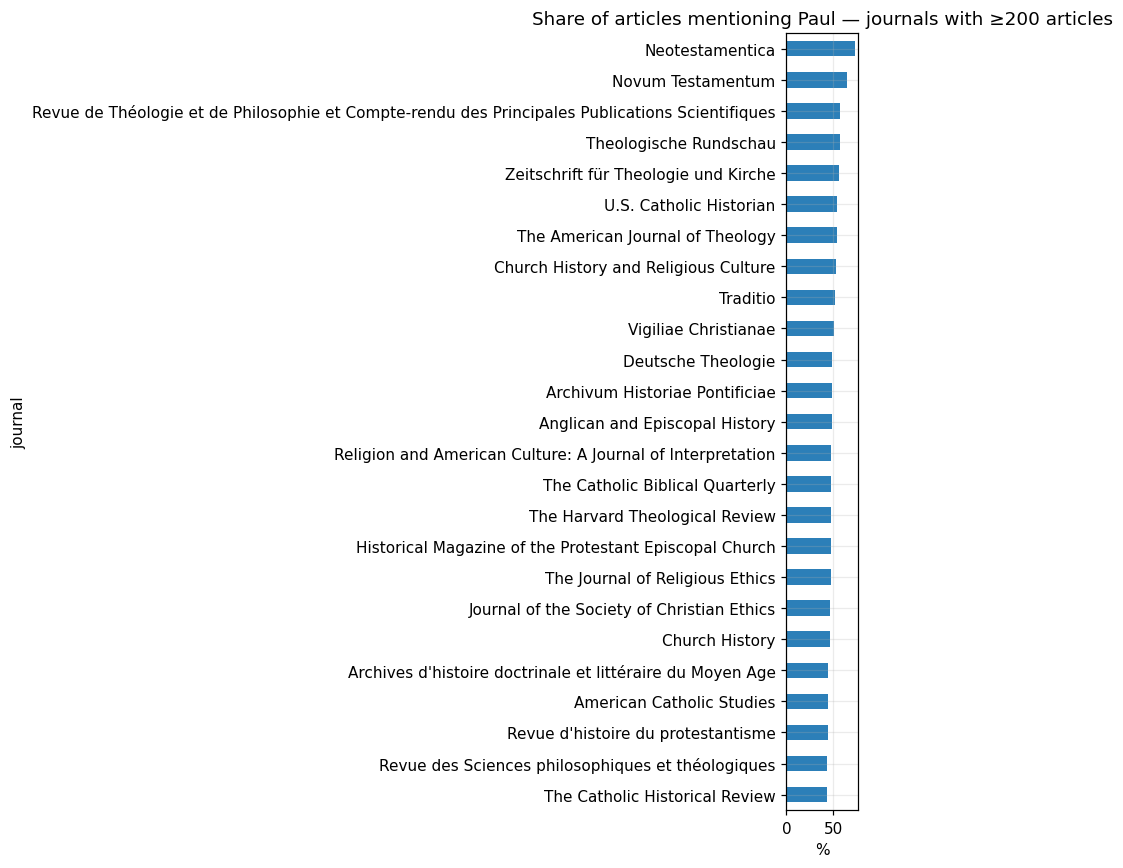

,with_hit,tier_a,tier_b,tier_c,articles,% articles w/ hit,A hits / article
journal,,,,,,,
Bulletin de théologie ancienne et médiévale,107,500,371,164,122,87.704918,4.098361
Neotestamentica,638,1938,5676,15106,879,72.582480,2.204778
Novum Testamentum,813,2458,10086,17388,1256,64.729299,1.957006
Revue de Théologie et de Philosophie et Compte-rendu des Principales Publications Scientifiques,475,1299,1251,1842,829,57.297949,1.566948
Theologische Rundschau,690,509,9864,522,1207,57.166529,0.421707
...,...,...,...,...,...,...,...
"The Journal of Philosophy, Psychology and Scientific Methods",19,9,6,17,1117,1.700985,0.008057
Pe'amim: Studies in Oriental Jewry / פעמים: רבעון לחקר קהילות ישראל במזרח,17,2,6,12,1161,1.464255,0.001723
Sefunot: Studies and Sources on the History of the Jewish Communities in the East / ספונות: מחקרים ומקורות לתולדות קהילות ישראל במזרח,4,0,2,2,278,1.438849,0.000000


In [17]:
arts = pd.read_csv(METADATA_CSV, usecols=["item_id", "is_part_of"]).rename(
    columns={"is_part_of": "journal"})
per = (by_doc.groupby("journal")
       .agg(with_hit=("item_id", "size"),
            tier_a=("tier_a", "sum"), tier_b=("tier_b", "sum"), tier_c=("tier_c", "sum")))
per = per.join(arts["journal"].value_counts().rename("articles"))
per["% articles w/ hit"] = 100 * per["with_hit"] / per["articles"]
per["A hits / article"] = per["tier_a"] / per["articles"]
per = per.sort_values("% articles w/ hit", ascending=False)

MIN_ARTICLES = 200
big = per[per["articles"] >= MIN_ARTICLES]
display(per.head(15))
big["% articles w/ hit"].nlargest(25)[::-1].plot.barh(figsize=(8, 8), color="#2c7fb8")
plt.title(f"Share of articles mentioning Paul — journals with ≥{MIN_ARTICLES} articles")
plt.xlabel("%"); plt.tight_layout(); plt.show()
per


## 5 · Flags: where the uncertainty lives

Each flag is a *signal*, not a verdict — `excluded_name` means a surname from
`paul_exclusions.txt` sits within ±46 characters, which catches *Paul Tillich* but can also
fire on a genuine reference that happens to cite a scholar named Paul.

,hits,in A,in B,in C,% of tier C
capital_after,57495,5478,26523,25494,12.4
probably_person_name,21443,0,0,21443,10.4
citation_apparatus,18265,4349,6776,7140,3.5
possibly_given_name,14952,914,13740,298,0.1
excluded_name,13692,1367,2255,10070,4.9
papacy_or_numeral,5918,581,3252,2085,1.0
demoted_name_after,4507,0,989,3518,1.7
place_or_building,3890,2792,982,116,0.1
initial_after,3819,130,660,3029,1.5
initial_before,3032,423,1124,1485,0.7


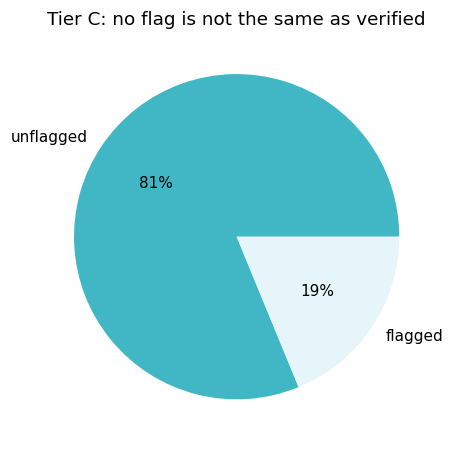

In [18]:
flag_tbl = pd.DataFrame({
    "hits": [int(hits[f"f_{f}"].sum()) for f in ALL_FLAGS],
    "in A": [int(hits.loc[hits.tier.eq("A"), f"f_{f}"].sum()) for f in ALL_FLAGS],
    "in B": [int(hits.loc[hits.tier.eq("B"), f"f_{f}"].sum()) for f in ALL_FLAGS],
    "in C": [int(hits.loc[hits.tier.eq("C"), f"f_{f}"].sum()) for f in ALL_FLAGS],
}, index=ALL_FLAGS).sort_values("hits", ascending=False)
flag_tbl["% of tier C"] = (100 * flag_tbl["in C"] / (hits.tier == "C").sum()).round(1)
display(flag_tbl)

hits.loc[hits.tier.eq("C"), "flagged"].map({True: "flagged", False: "unflagged"}) \
    .value_counts().plot.pie(autopct="%1.0f%%", ylabel="", colors=["#41b6c4", "#e5f5f9"],
                             title="Tier C: no flag is not the same as verified")
plt.show()


## 6 · Browsing the hits

No widget here: `ipywidgets` needs the notebook's JavaScript comm layer, which does not
work over a remote VSCode server (the widget renders as an empty box). The same filters
are keyword arguments instead, so a query is an ordinary cell you edit and rerun.

`q()` wraps `browse()` + `show_hits()`; every argument is optional.

| argument | meaning |
|---|---|
| `tier` | `"A"` unflagged reference, `"B"` demoted, `"C"` needs judgement |
| `pattern`, `journal`, `language` | exact value, e.g. `pattern="A4_tarsus"` |
| `year_from`, `year_to` | inclusive |
| `require_flag`, `exclude_flag` | one name from `ALL_FLAGS` |
| `unflagged_only` | rows no flag touched |
| `sentence=True` | whole sentences instead of KWIC |
| `n`, `seed` | sample size and seed — same `seed` returns the same rows |

In [ ]:
META = pd.read_csv(METADATA_CSV,
                   usecols=["item_id", "title", "is_part_of", "creators_string", "languages"]) \
         .set_index("item_id")

def jstor_text(item_id: str) -> str:
    """Full text as it sits on disk — char_start/char_end index into exactly this."""
    return (JSTOR_TEXTS / f"{item_id}.txt").read_text(encoding="utf-8")

def kwic(row, width=52) -> str:
    left, right = str(row["kwic_left"])[-width:], str(row["kwic_right"])[:width]
    return f"{left}[{row['match']}]{right}"

def _flagcol(d, name):
    """Flag columns are booleans, but a parquet round-trip can leave NA in them."""
    return d[f"f_{name}"].fillna(False).astype(bool)


def _flagcol(d, name):
    """Flag columns are booleans, but a parquet round-trip can leave NA in them."""
    return d[f"f_{name}"].fillna(False).astype(bool)


def browse(tier=None, pattern=None, journal=None, language=None,
           year_from=None, year_to=None, require_flag=None, exclude_flag=None,
           exclude_flags=(), unflagged_only=False, n=25, seed=0):
    """Filtered sample of hits, with article titles joined in."""
    d = hits
    for col, val in (("tier", tier), ("pattern", pattern), ("journal", journal),
                     ("language", language)):
        if val and val != "all":
            d = d[d[col] == val]
    if year_from: d = d[d["year"] >= year_from]
    if year_to:   d = d[d["year"] <= year_to]
    if require_flag and require_flag != "all": d = d[_flagcol(d, require_flag)]
    if exclude_flag and exclude_flag != "all": d = d[~_flagcol(d, exclude_flag)]
    for f in exclude_flags:
        if f: d = d[~_flagcol(d, f)]
    if unflagged_only: d = d[~d["flagged"].fillna(False)]
    sample = d.sample(min(n, len(d)), random_state=seed) if len(d) else d
    return sample.assign(share=100 * len(d) / len(hits),
                         title=lambda s: s["item_id"].map(META["title"]))

def show_hits(d, width=52, max_rows=None):
    for _, r in d.iterrows() if max_rows is None else d.head(max_rows).iterrows():
        print(f"{r['tier']} {r['pattern']:<26} {r['year']}  {str(r['title'])[:46]:<46}")
        print(f"     {kwic(r, width)}")
        if r["flags"]: print(f"     flags: {r['flags']}")
    print(f"\n{len(d)} of {int(d['share'].iloc[0]) if len(d) else 0:.1f}% of all hits "
          f"({d['item_id'].nunique()} articles shown)")


In [ ]:
def q(sentence=False, width=52, to_csv=None, n=25, seed=0, **filters):
    """Filter the hits and print them. Filters: tier, pattern, journal, language,
    year_from, year_to, require_flag, exclude_flag, exclude_flags, unflagged_only.
    """
    d = browse(n=n, seed=seed, **filters)
    if to_csv:
        d.to_csv(to_csv, index=False)
        print(f"wrote {len(d):,} rows -> {to_csv}\n")
    if sentence:
        for _, r in d.iterrows():
            print(f"[{r['tier']} · {r['pattern']} · {r['year']} · {r['journal']}]")
            print(str(r["sentence"])[:600])
            if r["flags"]: print(f"   flags: {r['flags']}")
            print()
    else:
        show_hits(d, width=width)
    return d

### The filters, in use

In [ ]:
q(tier="A", n=8)

Tier B is real references that a flag knocked down. This is where recall is lost, and it is the largest tier at 145,240 rows, so it is the one worth sampling.

In [ ]:
q(tier="B", n=15)

One construction, one era. `pattern` takes any of the 14 names in `sorted(hits['pattern'].unique())`.

In [ ]:
q(pattern="A4_tarsus", year_from=1950, year_to=1980, n=15)

The 11 flags in `ALL_FLAGS` are `capital_after`, `citation_apparatus`, `demoted_name_after`, `excluded_name`, `initial_after`, `initial_before`, `papacy_or_numeral`, `place_or_building`, `possibly_given_name`, `probably_person_name`, `running_head`. Each is also a boolean column `f_<name>`.

In [ ]:
q(require_flag="probably_person_name", n=12)

Rows no flag touched are the cleanest subset to check precision against by hand.

In [ ]:
q(unflagged_only=True, tier="A", n=15)

When a KWIC window is too short to judge, read the sentence. `width=` widens the window without going all the way to the whole sentence.

In [ ]:
q(tier="C", n=5, sentence=True)

`to_csv=` saves the filtered subset for any purpose — a table, a closer look, a hand-built sample. Labelling the precision sample is a separate, dedicated flow in §8 (`scripts/label_eval.py`), which writes its own review sheet and merges verdicts on `row_id`.

In [ ]:
q(tier="B", n=50, seed=7, to_csv="tierB_sample.csv")

## 7 · One article in its own context

`char_start`/`char_end` index the on-disk text verbatim (the matching copy is
length-preserving), so a hit can always be re-read in the article it came from.
This is also how to check whether the detector missed something — compare `n_hits`
against a manual count for the same string.

In [21]:
def article_hits(item_id: str, context: int = 160) -> None:
    """Every Paul hit in one article, in document order, inside its surrounding text."""
    text = jstor_text(item_id)
    d = hits[hits["item_id"] == item_id].sort_values("char_start")
    if not len(d):
        print("no hits for", item_id)
        return
    m = META.loc[item_id]
    print(f"{m['title']}\n{m['is_part_of']} · {m['creators_string']} · {d['year'].iloc[0]}"
          f"\n{len(text):,} chars, {len(d)} hits  ({', '.join(sorted(d['tier'].unique()))})\n" + "-" * 78)
    for _, r in d.iterrows():
        lo = max(0, r["char_start"] - context)
        hi = min(len(text), r["char_end"] + context)
        print(f"\n▶ {r['tier']} · {r['pattern']} · char {r['char_start']:,} · flags: {r['flags'] or '—'}")
        print(("…" if lo else "") + " ".join(text[lo:r['char_start']].split()) + " ⟦" +
              text[r['char_start']:r['char_end']] + "⟧ " +
              " ".join(text[r['char_end']:hi].split()) + ("…" if hi < len(text) else ""))

# A tier-A-dense article to start from; change to any item_id from §6.
example = (hits[hits["tier"].eq("A")]
           .groupby("item_id").size().sort_values(ascending=False).index[0])
print(example)
article_hits(example)


a0535e51-0d2a-38d5-a3a6-10d672efc909
TABLE ALPHABÉTIQUE DES TOMES I-LXXV 1892-1968
Revue Biblique (1946-) · J.-M. ROUSÉE · 1968
1,985,563 chars, 384 hits  (A, B, C)
------------------------------------------------------------------------------

▶ B · B3_of_paul · char 25,552 · flags: —
…(Goulder) 1968, 463-5. - Et tradition évangélique (Davies) 1963, 295-6. - Témoignage sur la sépulture de Jésus (Braun) 1936, 184-200. - Récits de la conversion ⟦de Paul⟧ (Lohfink) 1967, 293-4. - Pierre et Paul (Dupont) 1957, 35- 47. - Et l'épître aux Galates (Weber) 1901, 319-20. - Voyages de Paul à Jérusalem (Barnikol) 1929, 6…

▶ B · B3_of_paul · char 25,681 · flags: —
…200. - Récits de la conversion de Paul (Lohfink) 1967, 293-4. - Pierre et Paul (Dupont) 1957, 35- 47. - Et l'épître aux Galates (Weber) 1901, 319-20. - Voyages ⟦de Paul⟧ à Jérusalem (Barnikol) 1929, 607-9. - Et les Juifs (Baum) 1964, 82-3. - Théologie du Proto-Luc (Sahlin) 1947, 287-91. - Tendances théologiques du texte occiden…

▶ A ·

## 8 · Labelling the precision sample

`paul_eval.tsv` (280 rows, one per sampled hit) has an empty `verdict` column, and
precision per pattern cannot be published until it is filled in — the open item in
`AGENTS.md`.

**No widget and no `input()` here.** Both need something a notebook cell over a remote
VSCode server does not give you: widgets need the JavaScript comm layer, and an `input()`
prompt never appears (the cell only looks hung). What does work is the editor itself —
write a review sheet, fill its `verdict` column, save, merge it back.

Verdicts: `a`postle (a genuine reference to the apostle) · `o`ther · `u`nclear · `s`kip.
`skip` is recorded but excluded from precision; `unclear` sets its upper bound.

The current sample was drawn from the buggy 2026-09-04 run — regenerate it first with
`python3 scripts/paul_concordance.py --dump-eval 300`. Everything below goes through
`scripts/label_eval.py`, which is also a CLI, so a real terminal can instead run
`python3 scripts/label_eval.py interactive --tier B -n 50`.

In [ ]:
# One source of truth for labelling: scripts/label_eval.py, also a CLI.
import importlib.util as _ilu

_spec = _ilu.spec_from_file_location("label_eval", ROOT / "scripts" / "label_eval.py")
label_eval = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(label_eval)

_eval = label_eval.load_sample()          # paul_eval.tsv + any verdicts already saved
_done = _eval["verdict"].isin(label_eval.CANONICAL).sum()
print(f"{_done} of {len(_eval)} labelled, {len(_eval) - _done} to go")

### Write a review sheet

`--tier B` is the highest-value subset: 145,240 rows a flag demoted, so whatever recall
the flags cost is in there. `context` is the hit inside its sentence, wide enough to judge
from. `row_id` is the join key — leave it alone.

In [ ]:
SHEET = SCAN / "eval_sheet_B.tsv"
label_eval.make_sheet(_eval, SHEET, n=50, seed=7, tier="B", width=130)

Fill the `verdict` column in VSCode, save, then merge it back. Verdicts accumulate in
**`paul_eval.labelled.tsv`** and merge on `row_id`, so several sheets can be labelled in
any order; `paul_eval.tsv` itself is never modified.

In [ ]:
_eval = label_eval.apply_sheet(SHEET, _eval)

Precision from whatever is labelled so far.

In [ ]:
label_eval.report(_eval)

## 9 · Reading a reference list instead

`references_txts/` is deliberately **not** scanned, so `citation_apparatus` means "a
bibliography sitting in the body text", not an entry from the reference files. If a claim
needs *how often Paul is cited* rather than *mentioned*, that is a separate pass over
`references_txts/` — and this is where to start it.

In [ ]:
def references(item_id: str) -> list[str]:
    p = Path("/srv/data/jstor/jstor2026-04/references_txts") / f"{item_id}.txt"
    return p.read_text(encoding="utf-8").splitlines() if p.exists() else []

# Sample: in articles that mention Paul, how often does he appear in their bibliography?
cand = by_doc[by_doc["tier_a"] > 0]["item_id"].sample(300, random_state=1)
rows = []
for iid in cand:
    refs = references(iid)
    rows.append({"item_id": iid, "n_refs": len(refs),
                 "refs_with_paul": sum(bool(re.search(r"\bPaul(us)?\b", r)) for r in refs)})
sample_refs = pd.DataFrame(rows)
print(f"of {len(sample_refs)} tier-A articles sampled, "
      f"{(sample_refs['refs_with_paul'] > 0).mean():.0%} cite Paul in their bibliography "
      f"(median {int(sample_refs['refs_with_paul'].median())} entries, "
      f"of {int(sample_refs['n_refs'].median())} total)")
sample_refs.head()


## 10 · Starting points for specific questions

| question | where to look |
| --- | --- |
| how many explicit references? | `tier == "A"`, 76,163 hits / 26,263 articles — quote with the pattern breakdown, since A6 (`St. Paul`) is 52,207 of it and includes saints and places that survived the flags |
| references to the apostle specifically | `pattern` in `A1`–`A4` (~7.8k) — high precision by construction, low recall |
| the reception of Pauline writings | `A5_pauline_writings` + `B1_pauline_adj` |
| Latin-language scholarship | `pattern == "B2_paulus"`, `language` |
| is my count contaminated by modern Pauls? | filter on `f_probably_person_name`, `f_excluded_name`, `f_capital_after`, then eyeball with `browse()` above |
| denominational / confessional spread | `browse()` with `require_flag=None`, `journal` set, large `n` — then group by journal |
| comparison with the 2022–2025 study | `bidecade`, but note the old study read n-grams for 25,070 articles, not these 384,807 full texts |

Everything above is plain pandas on two TSVs; `duckdb` over `hits.tsv.gz` works too if a
query gets expensive.